In [1]:
import logging
import os
from pathlib import Path
import re

from IPython.display import Markdown, display
from matplotlib.figure import Figure
import matplotlib.pyplot as plt
import pandas as pd

from kibad_llm.config import PROJ_ROOT
from kibad_llm.utils.job_return import load_runs, mixed_group_by

# set INFO log level to show loaded file paths
logging.basicConfig(level=logging.INFO)

# swith to project root to use same paths as in commands
os.chdir(PROJ_ROOT)
# set wider column width for displaying pandas data frames
pd.set_option("max_colwidth", 400)
# show all columns
pd.set_option("display.max_columns", None)

logger = logging.getLogger(__name__)

# Some good defaults

BASE_LOG_DIR = Path("data/prediction_results/logs")

# don't load this data to declutter the data frames
EXCLUDE_KEYS = [
    "prediction.job_return_value.output_file",
    "prediction.job_return_value.output_file_absolute",
]
# set any missing (default) values as column name -> value
FILL_NA = {}
MAP_VALUES = None
# passed when plotting metrics and errors
FIGSIZE = (10, 10)
# if necessary, provide one or multiple subdirs
SUBDIR = "evaluate"
# optional prefix for plot file names
FILE_NAME_PREFIX = ""
METRICS = ["f1"]

2026-02-20 15:40:49.949 | INFO     | kibad_llm.config:<module>:11 - PROJ_ROOT path is: /home/arbi01/projects/kibad-llm


In [2]:
# POST YOUR "NOTEBOOK PARAMETERS" FROM THE EXPERIMENT README HERE

NAME = "311_better_default_temperature"
# used to group the data
INDEX_COLUMNS = ["prediction.overrides.extractor/llm"]
PLOT_KWARGS = {
    # can be either "metric" or one of the INDEX_COLUMNS (or multiple of them)
    "xgroup": "prediction.overrides.extractor/llm",
    # add any more arguments passed to pd.DataFrame.plot
}

# Load Run Data

In [3]:
all_df = pd.DataFrame.from_records(
    load_runs(
        directory=BASE_LOG_DIR / NAME,
        subdir=SUBDIR,
        exclude_keys=EXCLUDE_KEYS,
    )
)
if MAP_VALUES is not None:
    all_df = all_df.map(**MAP_VALUES)

all_df = all_df.fillna(FILL_NA)

# display(all_df)
# replace individual missing values with zero counts
errors_df = all_df[all_df["overrides.experiment/evaluate"] == "prediction_errors"].dropna(
    axis="columns", how="all"
)
# display(errors_df)
metrics_df = all_df[all_df["overrides.experiment/evaluate"] != "prediction_errors"].dropna(
    axis="columns", how="all"
)
metrics_df

INFO:kibad_llm.utils.job_return:Loading job_return_value.json from 30 files from the following parent directories (directory: data/prediction_results/logs/311_better_default_temperature, subdir: ['evaluate']):
data/prediction_results/logs/311_better_default_temperature/evaluate/multiruns/2026-01-30_14-40-58
data/prediction_results/logs/311_better_default_temperature/evaluate/multiruns/2026-01-30_14-41-58


,biodiversity_level.precision,biodiversity_level.recall,biodiversity_level.f1,biodiversity_level.support,ecosystem_type.term.precision,ecosystem_type.term.recall,ecosystem_type.term.f1,ecosystem_type.term.support,habitat.precision,habitat.recall,habitat.f1,habitat.support,taxa.german_name.precision,taxa.german_name.recall,taxa.german_name.f1,taxa.german_name.support,taxa.scientific_name.precision,taxa.scientific_name.recall,taxa.scientific_name.f1,taxa.scientific_name.support,taxa.species_group.precision,taxa.species_group.recall,taxa.species_group.f1,taxa.species_group.support,AVG.precision,AVG.recall,AVG.f1,AVG.support,ALL.precision,ALL.recall,ALL.f1,ALL.support,prediction.job_return_value.time_pdf_conversion,prediction.job_return_value.time_extraction,prediction.job_return_value.commit_hash,prediction.job_return_value.branch,prediction.job_return_value.is_dirty,prediction.overrides.name,prediction.overrides.experiment/predict,prediction.overrides.pdf_directory,prediction.overrides.extractor.return_reasoning,prediction.overrides.extractor/llm,prediction.overrides.seed,overrides.dataset.predictions.log,overrides.name,overrides.experiment/evaluate,overrides.prediction_logs
0,0.283582,0.283582,0.283582,67.0,0.277778,0.283019,0.280374,53.0,0.646465,0.463768,0.540084,138.0,0.104294,0.073593,0.086294,231.0,0.219409,0.263959,0.239631,197.0,0.457447,0.405660,0.430000,106.0,0.331496,0.295597,0.309994,132.0,0.294118,0.265152,0.278884,792.0,0.008129,1309.984350,7197d3bf97007b8a8e7b212a900e4c0bb574f62a,feature/temperature_config,False,311_better_default_temperature,faktencheck_core_fields_schema_with_evidence,/ds/text/kiba-d/dev-set-100,True,gpt_oss_20b_in_process,42,logs/311_better_default_temperature/predict/multiruns/2026-01-23_16-12-26/0,311_better_default_temperature,faktencheck_core_f1_micro_flat,logs/311_better_default_temperature/predict/multiruns/2026-01-23_16-12-26
1,0.289855,0.298507,0.294118,67.0,0.276923,0.339623,0.305085,53.0,0.606061,0.434783,0.506329,138.0,0.186813,0.147186,0.164649,231.0,0.202091,0.294416,0.239669,197.0,0.405405,0.424528,0.414747,106.0,0.327858,0.323174,0.320766,132.0,0.289053,0.296717,0.292835,792.0,0.006151,1427.458483,7197d3bf97007b8a8e7b212a900e4c0bb574f62a,feature/temperature_config,False,311_better_default_temperature,faktencheck_core_fields_schema_with_evidence,/ds/text/kiba-d/dev-set-100,True,gpt_oss_20b_in_process,1337,logs/311_better_default_temperature/predict/multiruns/2026-01-23_16-12-26/1,311_better_default_temperature,faktencheck_core_f1_micro_flat,logs/311_better_default_temperature/predict/multiruns/2026-01-23_16-12-26
2,0.253731,0.253731,0.253731,67.0,0.147059,0.094340,0.114943,53.0,0.490385,0.369565,0.421488,138.0,0.344828,0.086580,0.138408,231.0,0.126984,0.040609,0.061538,197.0,0.370370,0.283019,0.320856,106.0,0.288893,0.187974,0.218494,132.0,0.321867,0.165404,0.218515,792.0,0.008902,1031.851484,7197d3bf97007b8a8e7b212a900e4c0bb574f62a,feature/temperature_config,False,311_better_default_temperature,faktencheck_core_fields_schema_with_evidence,/ds/text/kiba-d/dev-set-100,True,gemma3_27b_in_process,7331,logs/311_better_default_temperature/predict/multiruns/2026-01-23_16-12-26/5,311_better_default_temperature,faktencheck_core_f1_micro_flat,logs/311_better_default_temperature/predict/multiruns/2026-01-23_16-12-26
3,0.258065,0.238806,0.248062,67.0,0.354430,0.528302,0.424242,53.0,0.761194,0.369565,0.497561,138.0,0.087500,0.030303,0.045016,231.0,0.350000,0.142132,0.202166,197.0,0.494505,0.424528,0.456853,106.0,0.384282,0.288939,0.312317,132.0,0.381264,0.220960,0.279776,792.0,0.006778,2600.602964,7197d3bf97007b8a8e7b212a900e4c0bb574f62a,feature/temperature_config,False,311_better_default_temperature,faktencheck_core_fields_schema_with_evidence,/ds/text/kiba-d/dev-set-100,True,qwen3_30b_in_process,42,logs/311_better_default_temperature/predict/multiruns/2026-01-23_16-12-26/6,311_better_default_temperature,faktencheck_core_f1_micro_flat,logs/311_better_default_temperature/predict/multiruns/202

# Check for Missing Values in `INDEX_COLUMNS`

In [4]:
mask = all_df[INDEX_COLUMNS].isna().any(axis=1)
rows_with_na = metrics_df.loc[mask, INDEX_COLUMNS]
if len(rows_with_na) > 0:
    na_cols = rows_with_na.columns[rows_with_na.isna().any()].tolist()
    help_str = {col: "SOME VALUE" for col in na_cols}
    logger.warning(
        f"NA values found in columns: {na_cols}. Consider adjusting the FILL_NA parameter!\n(i.e. set FILL_NA={help_str})\n",
    )
    not_numbers = metrics_df.select_dtypes(exclude="number")
    keep_cols = (not_numbers.nunique(dropna=False) > 1) | (not_numbers.isna().all())
    logger.info(
        f"Rows with NA values in INDEX_COLUMNS={INDEX_COLUMNS}:",
    )
    display(not_numbers.loc[mask, keep_cols])
else:
    logger.info("Everything is fine.")

INFO:__main__:Everything is fine.


# Show Some Grouping Result

In [5]:
cols = []
for metric in METRICS:
    cols.append(f"ALL.{metric}")
mixed_group_by(metrics_df[cols + INDEX_COLUMNS], by=INDEX_COLUMNS, columns_name="metric")

metric,ALL.f1
prediction.overrides.extractor/llm,
gemma3_27b_in_process,0.224706
gpt_oss_20b_in_process,0.290527
mistral_small_3_24b_in_process,0.253475
nemotron_nano_12b_in_process,0.195302
qwen3_30b_in_process,0.295946


# Single Setup or Comparison?

In [6]:
# we simple assume it is a comparison when we want to create subplots (this heuristic could be improved)
is_comparison = PLOT_KWARGS.get("create_subplot_for_each") is not None
logger.info(f"is_comparison: {is_comparison}")

INFO:__main__:is_comparison: False


In [7]:
def display_verbose(data: pd.DataFrame | None, verbose: bool, msg: str) -> None:
    if verbose and data is not None:
        logger.info(msg)
        display(data)


def get_grouped_y_and_yerr(
    data: pd.DataFrame,
    name: str,
    group_by: str | list[str],
    include_cols_regex: str | None = None,
    with_std_as_err: bool = True,
    verbose: bool = False,
):
    """Group and aggregate selected metric columns and optionally compute per-group error bars.

    This helper selects all columns whose name matches `include_cols_regex` (plus the grouping
    columns), groups the data by `group_by`, and computes the mean per group. If grouping
    reduces the number of rows (i.e., at least one group has multiple items) and
    `with_std_as_err` is enabled, it also computes the per-group standard deviation as an
    error estimate.

    Args:
        data: Input dataframe containing grouping columns and metric columns.
        name: Column name label used by `mixed_group_by` for the aggregated value column(s).
        group_by: Column name or list of column names to group by. A string is treated as a
            single grouping column.
        include_cols_regex: Regular expression used to select metric columns from `data.columns`.
            All matching columns are aggregated. If None, use all numeric columns.
        with_std_as_err: If True, compute standard deviation per group as `yerr` when grouping
            actually aggregates multiple rows. If False, `yerr` is always None.
        verbose: If True, log and display intermediate grouped DataFrames.

    Returns:
        A tuple `(y, yerr)` where:
            - `y` is the grouped mean DataFrame indexed by `group_by`.
            - `yerr` is the grouped standard deviation DataFrame (same shape/index as `y`)
              or None if not computed.
    """

    if isinstance(group_by, str):
        group_by = [group_by]

    if include_cols_regex is not None:
        cols = [col for col in data.columns if re.search(include_cols_regex, col)] + group_by
    else:
        cols = list(data.select_dtypes(include="number").columns) + group_by
    logger.info(f"use columns (name={name}): {cols}")

    # create grouped dataframe with mean (and std), indexed by 'by' columns
    y = mixed_group_by(data[cols], by=group_by, numeric_agg_func="mean", columns_name=name)
    display_verbose(data=y, msg=f"grouped data (by={group_by})):", verbose=verbose)
    # only calculate stddev when grouping reduced the number of rows
    if with_std_as_err and len(y) < len(data):
        yerr = mixed_group_by(
            data[cols], by=group_by, numeric_agg_func="std", columns_name=name
        ).fillna(0.0)
        display_verbose(data=yerr, msg=f"grouped stddev data (by={group_by}):", verbose=verbose)
    else:
        yerr = None

    return y, yerr


def plot(
    data: pd.DataFrame,
    index_column: str | list[str],
    include_cols_regex: str | None = None,
    create_subplot_for_each: str | list[str] | None = None,
    xgroup: str | list[str] | None = None,
    with_std_as_err: bool = True,
    set_missing_values_to_zero: bool = False,
    name: str = "metric",
    figsize: tuple[int, int] = (15, 15),
    subplot_columns: int | None = None,
    subplot_rows: int | None = None,
    shorten_labels: bool = True,
    legend_kwargs: dict | None = None,
    verbose: bool = False,
    **plot_kwargs,
) -> Figure:
    """Plot grouped metric means as bar charts, optionally split into subplots and/or grouped bars.

    The function aggregates `data` by `index_column` (mean over all selected metric columns) and
    creates bar plots from the aggregated values. Metric columns are either selected via
    `include_cols_regex` or, if it is None, taken as all numeric columns. If `with_std_as_err`
    is enabled and the grouping reduces the number of rows, per-group standard deviations are
    computed and shown as error bars.

    Subplots are controlled via `create_subplot_for_each`: when provided, the aggregated result is
    reshaped so that each level listed there becomes a separate subplot. Within each subplot, bars
    can be further grouped by unstacking `xgroup`.

    Args:
        data: Input dataframe containing grouping columns and metric columns.
        index_column: Column name or list of column names to group by (x-axis categories). A list
            produces a MultiIndex grouping.
        include_cols_regex: Regular expression used to select metric columns to include. If None,
            use all numeric columns.
        create_subplot_for_each: Optional index level name(s) (from the grouped index, or the stacked
            metric level) that should become separate subplots. If None, all results are plotted in a
            single axes.
        xgroup: Optional index level name or list of names to unstack within each subplot, creating
            grouped bars along the x-axis.
        with_std_as_err: If True, compute and display per-group standard deviation as error bars when
            the grouping aggregates multiple rows.
        set_missing_values_to_zero: If entries are missing, set them to zero instead of removing the
            whole row or column.
        name: Label used as the aggregation column label (and as the stacked metric level name).
        figsize: Base figure size; height is multiplied by the number of subplots created.
        subplot_columns: When multiple subplots get created, arange them at this amount of columns.
        subplot_rows: When multiple subplots get created, arange them at this amount of rows.
        shorten_labels: If enabled, shorten labels by splitting at "." and keeping only the last part.
        legend_kwargs: Optional dictionary of keyword argumends passed to ax.legend() if available.
            If not provided, ax.legend() is not explicitly called.
        verbose: If True, log and display intermediate grouped/reshaped data.
        **plot_kwargs: Additional keyword arguments forwarded to pandas' `plot` call(s).

    Returns:
        The Matplotlib `Figure` containing the bar chart(s).
    """

    y, yerr = get_grouped_y_and_yerr(
        data=data,
        name=name,
        group_by=index_column,
        include_cols_regex=include_cols_regex,
        with_std_as_err=with_std_as_err,
        verbose=verbose,
    )

    if not isinstance(xgroup, list):
        xgroup = [xgroup]

    # reshape to series with multiindex: [index_column] + [name]
    y_series = y.stack()
    display_verbose(data=y_series, msg="stacked data:", verbose=verbose)
    yerr_series = yerr.stack() if yerr is not None else None

    if create_subplot_for_each is not None:
        if isinstance(create_subplot_for_each, str):
            create_subplot_for_each = [create_subplot_for_each]

        # ensure that all create_subplot_for_each entries are in the index
        missing_entries = set(create_subplot_for_each) - set(y_series.index.names)
        if len(missing_entries) > 0:
            raise ValueError(
                f"create_subplot_for_each entries '{missing_entries}' not in DataFrame index created from index_column + '{name}': {y_series.index.names}"
            )

        # reshape again to DataFrame subplots by unstacking the specified index levels
        y_plots = y_series.unstack(create_subplot_for_each)

        # bring yerr to the same shape if present
        yerr_plots = (
            yerr_series.unstack(create_subplot_for_each) if yerr_series is not None else None
        )
    else:
        # create dummy dataframes with a single column to match the expected shape
        # use title (if provided) include_cols_regex as column name (will be used as plot title)
        title = plot_kwargs.pop("title", None) or include_cols_regex
        y_series.name = title
        if yerr_series is not None:
            yerr_series.name = title

        y_plots = pd.concat([y_series], axis=1)
        yerr_plots = pd.concat([yerr_series], axis=1) if yerr_series is not None else None

    display_verbose(
        data=y_plots,
        msg=f"reshaped data (create_subplot_for_each={create_subplot_for_each}):",
        verbose=verbose,
    )
    display_verbose(
        data=yerr_plots,
        msg=f"reshaped stddev data (create_subplot_for_each={create_subplot_for_each}):",
        verbose=verbose,
    )

    # get columns containing NA values
    y_columns_contain_na = y_plots.isna().aggregate("any")
    y_na_columns = y_columns_contain_na[y_columns_contain_na].index
    if len(y_na_columns) > 0:
        display_verbose(
            data=y_plots[y_na_columns],
            # msg=f"drop columns containing NA values (y_na_columns={y_na_columns}):",
            msg=(
                f"set missing values to zero (y_na_columns={y_na_columns}):"
                if set_missing_values_to_zero
                else f"drop rows containing NA values (y_na_columns={y_na_columns}):"
            ),
            verbose=True,
        )
        if set_missing_values_to_zero:
            y_plots = y_plots.fillna(0)
            yerr_plots = yerr_plots.fillna(0) if yerr_plots is not None else None
        else:
            y_plots = y_plots.drop(labels=y_na_columns, axis="columns")
            yerr_plots = (
                yerr_plots.drop(labels=y_na_columns, axis="columns")
                if yerr_plots is not None
                else None
            )

    num_subplots = len(y_plots.columns)
    if subplot_columns is not None and subplot_rows is not None:
        raise ValueError("either subplot_columns or subplot_rows can be set, not both")
    if subplot_columns is not None:
        ncols = min(subplot_columns, num_subplots)
        nrows = ((num_subplots - 1) // ncols) + 1
    elif subplot_rows is not None:
        nrows = min(subplot_rows, num_subplots)
        ncols = ((num_subplots - 1) // nrows) + 1
    else:
        nrows = num_subplots
        ncols = 1
    multi_figsize = (figsize[0] * ncols, figsize[1] * nrows)
    # don't squeeze so we get an array also in the single column case (to work with loop below)
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols, figsize=multi_figsize, squeeze=False
    )  # , sharex=True)

    # create subplot for each column
    for i, (col, ax) in enumerate(zip(y_plots.columns, axes.flatten())):
        current_plot_kwargs = dict(plot_kwargs)
        y_plot = y_plots[col]
        yerr_plot = yerr_plots[col] if yerr_plots is not None else None

        display_verbose(data=y_plot, msg=f"y_plot (col={col}):", verbose=verbose)
        display_verbose(data=yerr_plot, msg=f"yerr_plot (col={col}):", verbose=verbose)

        # for grouping, create a dataframe by unstacking the respective level(s)
        if xgroup is not None:
            y_plot = y_plot.unstack(xgroup)
            # TODO: fix y_plot.columns.names (is is currently [None,] + xgroup)
            if yerr_plot is not None:
                yerr_plot = yerr_plot.unstack(xgroup)
                yerr_plot.columns.names = y_plot.columns.names

            display_verbose(data=y_plot, msg=f"y_plot grouped (xgroup={xgroup}):", verbose=verbose)
            display_verbose(
                data=yerr_plot, msg=f"yerr_plot grouped (xgroup={xgroup}):", verbose=verbose
            )

            y_na_rows_contain_na = y_plot.isna().aggregate("any", axis="columns")
            y_na_index = y_plot[y_na_rows_contain_na].index
            if len(y_na_index) > 0:
                display_verbose(
                    data=y_plot.loc[y_na_index],
                    msg=(
                        f"set missing values to zero (y_na_index={y_na_index}):"
                        if set_missing_values_to_zero
                        else f"drop rows containing NA values (y_na_index={y_na_index}):"
                    ),
                    verbose=True,
                )
                if set_missing_values_to_zero:
                    y_plot = y_plot.fillna(0)
                    yerr_plot = yerr_plot.fillna(0) if yerr_plot is not None else None
                else:
                    y_plot = y_plot.drop(labels=y_na_index, axis="index")
                    yerr_plot = (
                        yerr_plot.drop(labels=y_na_index, axis="index")
                        if yerr_plot is not None
                        else None
                    )

        if shorten_labels:
            y_plot.index.names = [
                idx.split(".")[-1] if idx is not None else None for idx in y_plot.index.names
            ]
            if isinstance(y_plot, pd.DataFrame):
                y_plot.columns.names = [
                    idx.split(".")[-1] if idx is not None else None for idx in y_plot.columns.names
                ]

        if current_plot_kwargs.get("title") is None:
            current_plot_kwargs["title"] = f"{col}"

        y_plot.plot(
            ax=ax,
            kind="bar",
            yerr=yerr_plot,
            **current_plot_kwargs,
        )
        if legend_kwargs is not None:
            ax.legend(**legend_kwargs)

    # remove empty subplots (happens when
    for i in range(len(y_plots.columns), len(axes.flatten())):
        i_col = i % ncols
        i_row = i // ncols
        logger.info(f"delete empty ax: i_row={i_row}, i_col={i_col}")
        fig.delaxes(axes[i_row][i_col])

    fig.tight_layout()
    return fig

# Metrics

## metric: f1

INFO:__main__:use columns (name=metric): ['biodiversity_level.f1', 'ecosystem_type.term.f1', 'habitat.f1', 'taxa.german_name.f1', 'taxa.scientific_name.f1', 'taxa.species_group.f1', 'ALL.f1', 'prediction.overrides.extractor/llm']


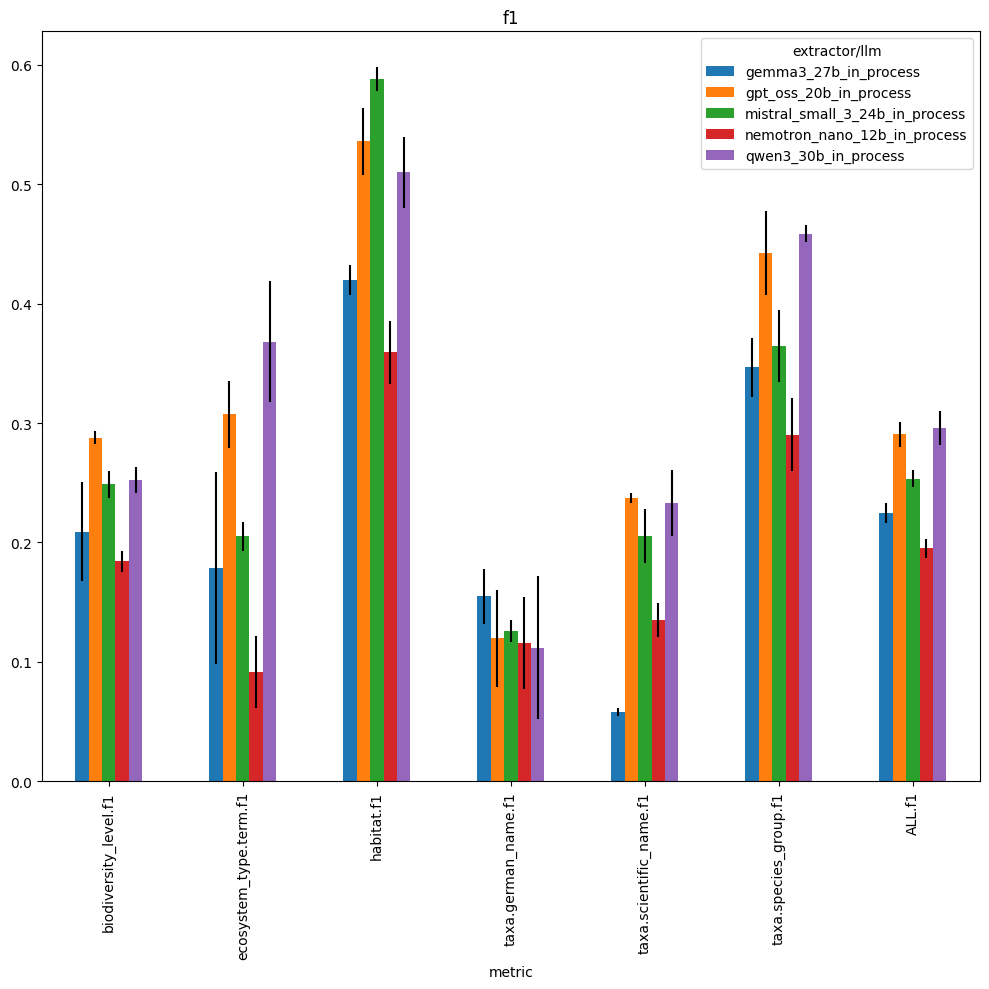

In [8]:
# set missing entries to zero (float since these are scores)
metrics_df_plot = metrics_df.fillna(0.0)
for metric in METRICS:
    # show some header
    display(Markdown(f"## metric: {metric}"))

    fig = plot(
        data=metrics_df_plot,
        index_column=INDEX_COLUMNS,
        include_cols_regex=f"[^G]\\.{metric}" if not is_comparison else f"ALL.{metric}",
        title=metric,
        # enable to show interim dataframes
        # verbose=True,
        figsize=FIGSIZE,
        **PLOT_KWARGS,
    )
    display(fig)

    # save metrics plot
    file_name = (
        FILE_NAME_PREFIX + ("comparison_" if is_comparison else "") + f"metrics_{metric}.svg"
    )
    fig.savefig(BASE_LOG_DIR / NAME / file_name)

    # to not show the figure twice
    plt.close(fig)

    if is_comparison:
        fig = plot(
            data=metrics_df_plot,
            index_column=INDEX_COLUMNS,
            include_cols_regex=f"[^GL]\\.{metric}",
            # enable to show interim dataframes
            # verbose=True,
            figsize=FIGSIZE,
            **PLOT_KWARGS,
        )
        display(fig)
        # save metrics detail plot
        file_name = (
            FILE_NAME_PREFIX
            + ("comparison_" if is_comparison else "")
            + f"metrics_{metric}_detail.svg"
        )
        fig.savefig(BASE_LOG_DIR / NAME / file_name)
        # to not show the figure twice
        plt.close(fig)

# Support

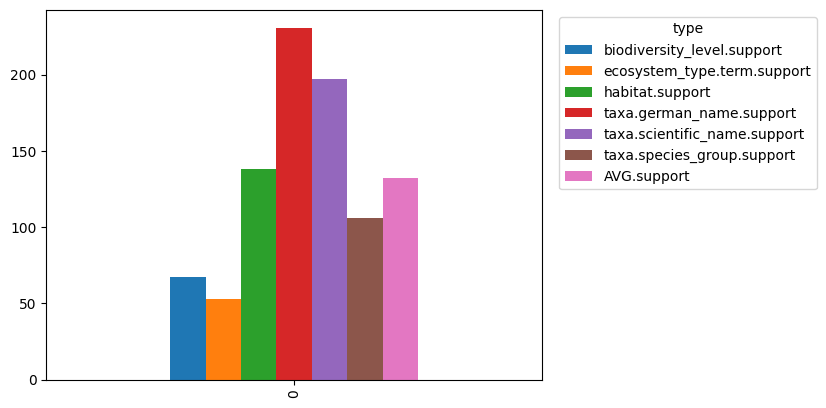

In [9]:
cols_to_plot = [col for col in metrics_df.columns if "support" in col and "ALL" not in col]
# get the first row, but as dataframe so that we have color-coded bars and a legend
ax = metrics_df[cols_to_plot].iloc[0:1].plot(kind="bar")
ax.legend(title="type", bbox_to_anchor=(1.02, 1), loc="upper left")
# ax.figure.tight_layout()

# Errors

In [10]:
# we analyse error counts, so aggregate by summing them up
errors_df_avg = mixed_group_by(errors_df, by=INDEX_COLUMNS)
errors_df_avg

,prediction.job_return_value.time_pdf_conversion,prediction.job_return_value.time_extraction,no_error,with_error,ValueError,JSONDecodeError,MissingResponseContentError,prediction.job_return_value.commit_hash,prediction.job_return_value.branch,prediction.job_return_value.is_dirty,prediction.overrides.name,prediction.overrides.experiment/predict,prediction.overrides.pdf_directory,prediction.overrides.extractor.return_reasoning,prediction.overrides.seed,overrides.dataset.predictions.log,overrides.name,overrides.experiment/evaluate,overrides.prediction_logs
prediction.overrides.extractor/llm,,,,,,,,,,,,,,,,,,,
gemma3_27b_in_process,0.007432,1017.395094,84.333333,15.666667,15.0,1.0,<NA>,"[7197d3bf97007b8a8e7b212a900e4c0bb574f62a, 7197d3bf97007b8a8e7b212a900e4c0bb574f62a, 7197d3bf97007b8a8e7b212a900e4c0bb574f62a]","[feature/temperature_config, feature/temperature_config, feature/temperature_config]","[False, False, False]","[311_better_default_temperature, 311_better_default_temperature, 311_better_default_temperature]","[faktencheck_core_fields_schema_with_evidence, faktencheck_core_fields_schema_with_evidence, faktencheck_core_fields_schema_with_evidence]","[/ds/text/kiba-d/dev-set-100, /ds/text/kiba-d/dev-set-100, /ds/text/kiba-d/dev-set-100]","[True, True, True]","[7331, 42, 1337]","[logs/311_better_default_temperature/predict/multiruns/2026-01-23_16-12-26/5, logs/311_better_default_temperature/predict/multiruns/2026-01-23_16-12-26/3, logs/311_better_default_temperature/predict/multiruns/2026-01-23_16-12-26/4]","[311_better_default_temperature, 311_better_default_temperature, 311_better_default_temperature]","[prediction_errors, prediction_errors, prediction_errors]","[logs/311_better_default_temperature/predict/multiruns/2026-01-23_16-12-26, logs/311_better_default_temperature/predict/multiruns/2026-01-23_16-12-26, logs/311_better_default_temperature/predict/multiruns/2026-01-23_16-12-26]"
gpt_oss_20b_in_process,0.006897,1422.42453,84.666667,15.333333,15.0,1.0,<NA>,"[7197d3bf97007b8a8e7b212a900e4c0bb574f62a, 7197d3bf97007b8a8e7b212a900e4c0bb574f62a, 7197d3bf97007b8a8e7b212a900e4c0bb574f62a]","[feature/temperature_config, feature/temperature_config, feature/temperature_config]","[False, False, False]","[311_better_default_temperature, 311_better_default_temperature, 311_better_default_temperature]","[faktencheck_core_fields_schema_with_evidence, faktencheck_core_fields_schema_with_evidence, faktencheck_core_fields_schema_with_evidence]","[/ds/text/kiba-d/dev-set-100, /ds/text/kiba-d/dev-set-100, /ds/text/kiba-d/dev-set-100]","[True, True, True]","[42, 1337, 7331]","[logs/311_better_default_temperature/predict/multiruns/2026-01-23_16-12-26/0, logs/311_better_default_temperature/predict/multiruns/2026-01-23_16-12-26/1, logs/311_better_default_temperature/predict/multiruns/2026-01-23_16-12-26/2]","[311_better_default_temperature, 311_better_default_temperature, 311_better_default_temperature]","[prediction_errors, prediction_errors, prediction_errors]","[logs/311_better_default_temperature/predict/multiruns/2026-01-23_16-12-26, logs/311_better_default_temperature/predict/multiruns/2026-01-23_16-12-26, logs/311_better_default_temperature/predict/multiruns/2026-01-23_16-12-26]"
mistral_small_3_24b_in_process,0.008518,2840.155729,78.666667,21.333333,15.0,6.333333,<NA>,"[7197d3bf97007b8a8e7b212a900e4c0bb574f62a, 7197d3bf97007b8a8e7b212a900e4c0bb574f62a, 7197d3bf97007b8a8e7b212a900e4c0bb574f62a]","[feature/temperature_config, feature/temperature_config, feature/temperature_config]","[False, False, False]","[311_better_default_temperature, 311_better_default_temperature, 311_better_default_temperature]","[faktencheck_core_fields_schema_with_evidence, faktencheck_core_fields_schema_with_evidence, faktencheck_core_fields_schema_with_evidence]","[/ds/text/kiba-d/dev-set-100, /ds/text/kiba-d/dev-set-100, /ds/text/kiba-d/dev-set-100]","[True, True, True]","[42, 1337, 7331]","[logs/311_better_default_temperature/predict/multiruns/2026-01-23_16

INFO:__main__:use columns (name=metric): ['no_error', 'with_error', 'prediction.overrides.extractor/llm']


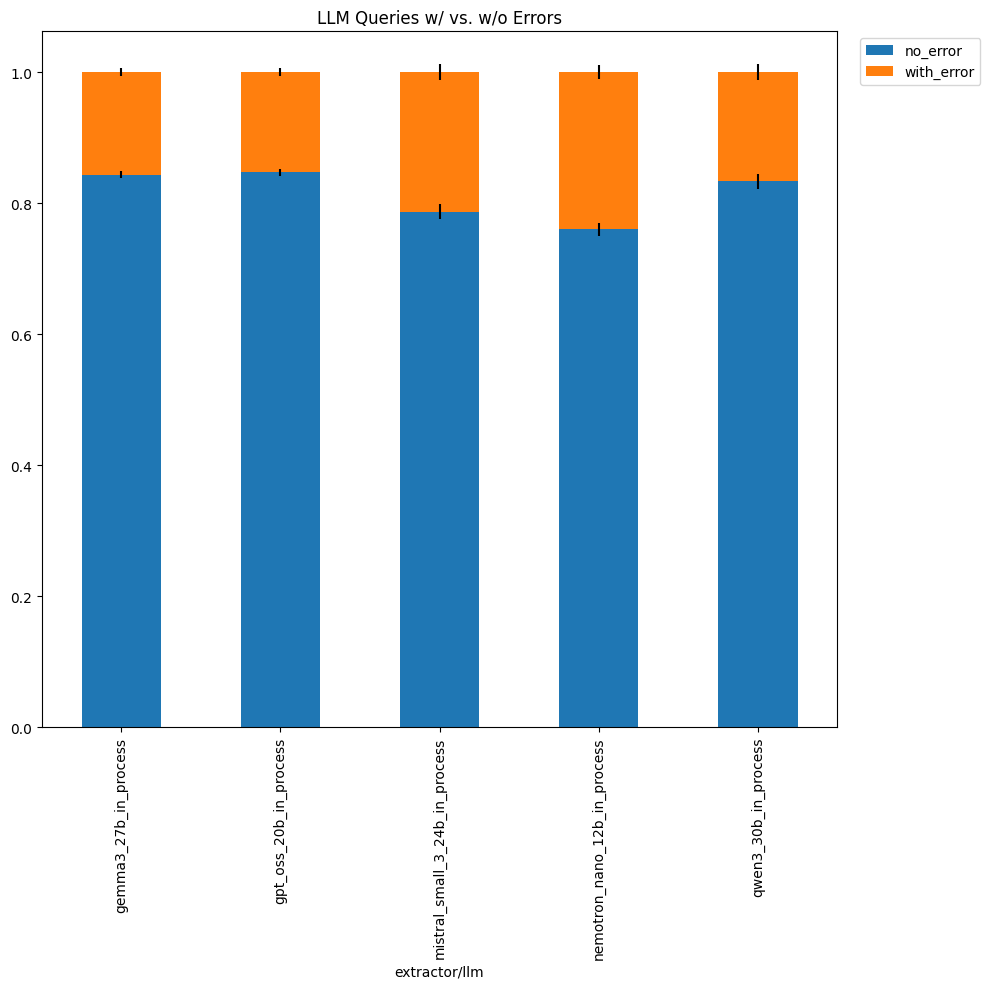

In [11]:
# set missing entries to zero (int since these are counts)
errors_df_plot = errors_df.fillna(0)

# normalize by number of queries
queries_total = errors_df_plot["with_error"] + errors_df_plot["no_error"]
errors_normalized_df_plot = errors_df_plot.copy()

errors_include_cols_regex = r"error"
# normalize respective columns
errors_cols = [col for col in errors_df_plot.columns if re.search(errors_include_cols_regex, col)]
for col in errors_cols:
    errors_normalized_df_plot[col] = errors_df_plot[col] / queries_total


if not is_comparison:
    # show with stddev
    PLOT_ERRORS_SINGLE_KWARGS = {
        "xgroup": "metric",
        "stacked": True,
        # put legend outside at the right
        "legend_kwargs": dict(bbox_to_anchor=(1.02, 1), loc="upper left"),
    }
    fig = plot(
        errors_normalized_df_plot,
        index_column=INDEX_COLUMNS,
        include_cols_regex=errors_include_cols_regex,
        **PLOT_ERRORS_SINGLE_KWARGS,
        # use PLOT_KWARGS instead of PLOT_ERRORS_SINGLE_KWARGS for A/B comparisons
        # **PLOT_KWARGS,
        figsize=FIGSIZE,
        title="LLM Queries w/ vs. w/o Errors",
    )
else:
    fig = plot(
        errors_normalized_df_plot,
        index_column=INDEX_COLUMNS,
        include_cols_regex=errors_include_cols_regex,
        **PLOT_KWARGS,
        figsize=FIGSIZE,
        title="LLM Queries with Errors",
    )

In [12]:
# save the errors plot
file_name = FILE_NAME_PREFIX + ("comparison_" if is_comparison else "") + "errors.svg"
fig.savefig(BASE_LOG_DIR / NAME / file_name)

INFO:__main__:use columns (name=metric): ['ValueError', 'JSONDecodeError', 'MissingResponseContentError', 'prediction.overrides.extractor/llm']


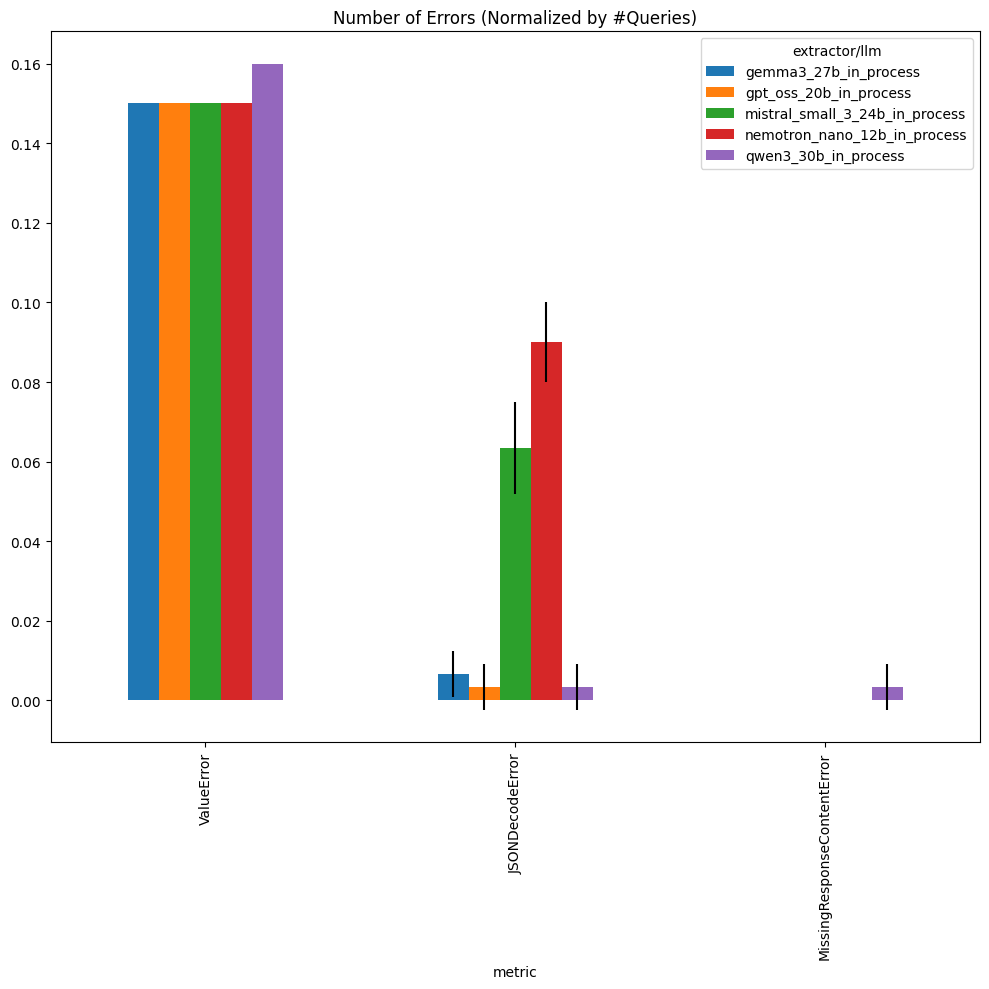

In [13]:
include_cols_regex = r"Error"
# normalize respective columns
errors_detail_cols = [col for col in errors_df_plot.columns if re.search(include_cols_regex, col)]
for col in errors_detail_cols:
    errors_normalized_df_plot[col] = errors_df_plot[col] / queries_total

fig = plot(
    # use errors_df_plot to get plots for unnormalized data
    errors_normalized_df_plot,
    index_column=INDEX_COLUMNS,
    include_cols_regex=include_cols_regex,
    **PLOT_KWARGS,
    figsize=FIGSIZE,
    title="Number of Errors (Normalized by #Queries)" if not is_comparison else None,
)

In [14]:
# save the errors plot
file_name = FILE_NAME_PREFIX + ("comparison_" if is_comparison else "") + "errors_detail.svg"
fig.savefig(BASE_LOG_DIR / NAME / file_name)